# Mirror Descent on Linear Objectives

For linear objectives over a simplex, optimum lies at a vertex.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython
ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)
OUT = Path(".")

def proj_simplex(v):
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u)
    rho = np.nonzero(u * np.arange(1, len(v)+1) > (cssv - 1))[0][-1]
    theta = (cssv[rho] - 1)/(rho+1)
    return np.maximum(v-theta,0)


## 2D simplex trajectory


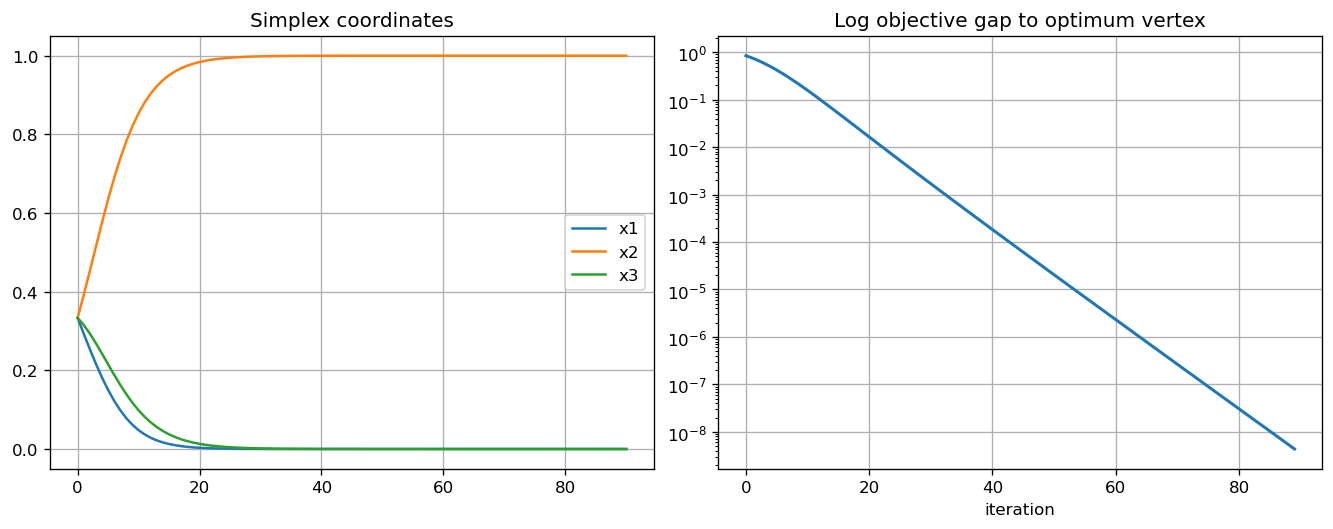

In [2]:
c = np.array([1.2, -0.4, 0.8])   # linear objective c^T x
x = np.array([1/3, 1/3, 1/3], float)
eta = 0.18
traj = [x.copy()]
vals = []
for _ in range(90):
    x = x * np.exp(-eta*c)
    x = x / x.sum()
    traj.append(x.copy())
    vals.append(c @ x)
traj = np.array(traj)
fstar = np.min(c)
gap = np.maximum(np.array(vals) - fstar, 1e-14)

fig, axes = plt.subplots(1,2, figsize=(11,4.3), constrained_layout=True)
axes[0].plot(traj[:,0], label='x1'); axes[0].plot(traj[:,1], label='x2'); axes[0].plot(traj[:,2], label='x3')
axes[0].set_title('Simplex coordinates')
axes[0].legend()
axes[1].semilogy(gap, lw=1.8)
axes[1].set_title('Log objective gap to optimum vertex')
axes[1].set_xlabel('iteration')
fig.savefig(OUT / "snippet.png", bbox_inches='tight')
plt.show()


## High-dimensional simplex convergence


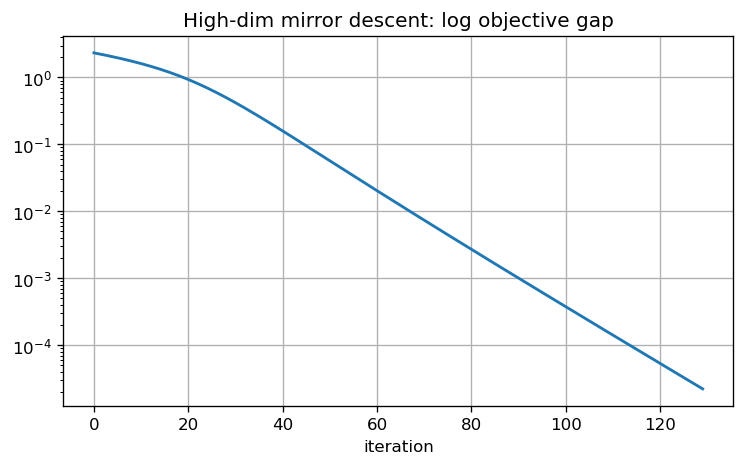

In [3]:
d = 60
c = rng.normal(size=d)
x = np.ones(d)/d
eta = 0.09
vals = []
for _ in range(130):
    x = x * np.exp(-eta*c)
    x = x / x.sum()
    vals.append(c @ x)
gap = np.maximum(np.array(vals) - np.min(c), 1e-14)

fig, ax = plt.subplots(figsize=(7.2, 4))
ax.semilogy(gap, lw=1.7)
ax.set_title('High-dim mirror descent: log objective gap')
ax.set_xlabel('iteration')
plt.show()
